# Percent Operating Accruals -- does scaling accruals by *earnings* beat scaling by *assets*?
### The Hafzalla-Lundholm-Van Winkle (2011) percent-accruals sort on a large-cap survivor basket

![Signal None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square) ![Tradability Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square) ![HLVW sharper Busted](https://img.shields.io/badge/HLVW_sharper_sort-Busted-8b949e?style=flat-square)

Sloan (1996) scaled operating accruals (Net Income minus Operating Cash Flow) by total assets and found high-accrual firms underperform. HLVW (2011) said: scale by the *magnitude of earnings* instead, and the sort gets *sharper*. We test that claim on 40 large-cap names using real SEC 10-K filings, and ask whether the percent-scaling really beats the asset-scaling on a 2009-2025 survivor panel.

> This is the plain-language layer. The HAC t-stats, label-shuffle placebo, and random-portfolio null live in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart drawn by the code beside it.
>
> **Survivorship bias**: the basket is large caps still trading in 2026. The high-accrual firms that collapsed and delisted are absent. Every number below is an upper bound.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from percent_operating_accruals import data, strategy as st

# Load this study's cached real tape; fall back gracefully to the frozen R dict.
sig, fwd = data.load_panel()
HAVE_REAL = not sig.empty
h = st.quintile_returns(sig, fwd, q=0.20, min_names=15) if HAVE_REAL else pd.DataFrame()

print("Real tape loaded:", HAVE_REAL,
      f"({len(sig.columns) if HAVE_REAL else 0} tickers, {len(sig) if HAVE_REAL else 0} years)")

# The ONE dict of real numbers — mirrors docs/results.md (as-of 2026-06-26).
R = dict(
    n_tickers=40, n_years=17, start_year=2009, end_year=2025,
    q1_mean=16.3, q1_t=7.28, q5_mean=13.7, q5_t=4.81,
    mkt_mean=15.7, mkt_t=10.47,
    hedge_gross=2.6, hedge_t=0.84, hedge_hit=47,
    hedge_net=1.9, hedge_net_t=0.64, turnover=62,
    lo_excess=0.6, lo_excess_t=0.29,
    hi_excess=-2.0, hi_excess_t=-1.06,
    placebo_p=0.46, placebo_null_t=0.11, placebo_null_std=1.23,
    rand_std=7.6, rand_pct_beaten=54,
    syn_null_t=0.02, syn_strong_t=9.89, syn_null_single=2.58,
    sloan_t=2.73,
)
Q1  = [14.8, 19.2, 3.0, 38.1, 33.7, 13.2, 5.5, 24.6, 11.8, -5.8, 28.8, 6.1, 22.1, 10.4, 31.7, -10.5, 30.1]
Q5  = [24.7, 16.5, 3.2, 10.7, 28.3, 17.8, 9.2, 10.5, 16.9, -5.3, 24.9, -2.3, 27.8, -15.2, -0.8, 31.3, 35.3]
MKT = [23.9, 17.6, 7.4, 18.7, 28.5, 16.0, 4.8, 15.5, 25.8, -1.8, 28.7, 7.8, 26.8, -4.6, 14.9, 18.0, 19.6]
HDG = [-9.9, 2.7, -0.2, 27.4, 5.4, -4.5, -3.7, 14.1, -5.1, -0.4, 3.9, 8.5, -5.6, 25.7, 32.5, -41.8, -5.3]
YRS = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


Real tape loaded: True (40 tickers, 20 years)


## The answer first

| Question | What the data says |
|---|---|
| Does low percent-accruals beat high? | Barely -- by **+2.6%/yr** gross, positive in only **47%** of years. |
| Is that statistically real? | No. HAC *t* = **0.84** -- well below |t| >= 2. After costs: +1.9%/yr, *t* = 0.64. |
| Does it survive a label shuffle? | No -- shuffled labels reproduce the real *t* **46%** of the time (*p* = 0.46). |
| Does the sort even line up? | No -- it is **non-monotone**: Q2 (16%-ish) leads, not Q1. The low-PA leg's excess is +0.6%/yr (*t* = +0.29). |
| Does earnings-scaling beat Sloan's asset-scaling? | No -- Sloan (Study 231) reached *t* = +2.73 on a comparable panel; this lands +0.84. |

> **The punchline**: on large-cap survivors, HLVW's sharper-sort claim does not replicate. The percent-accruals hedge is indistinguishable from random.

## 1 - The claim

> *Don't scale accruals by total assets (Sloan). Scale them by the size of earnings. Firms whose reported profit is mostly accruals (not cash) will underperform; firms whose profit is cash-backed will outperform. Sort on that fraction and the spread is bigger than Sloan's.*

- **operating accruals** = Net Income - Operating Cash Flow
- **percent accruals** = (Net Income - Operating Cash Flow) / |Net Income|

A high percent-accruals number means most of the profit is *not* backed by cash. HLVW (2011) argue this ranks earnings quality more cleanly than dividing the same accrual by firm size.

## 2 - So what?

If percent accruals sort returns more sharply than Sloan accruals, it would be a free upgrade: same two income-statement/cash-flow lines, a different denominator, a bigger long-short spread. HLVW reported a value-weighted hedge larger than Sloan's on 1989-2008 US stocks. If it *doesn't* replicate on large caps, that's a lesson in how published anomalies decay precisely where capital concentrates.

## 3 - How would we even know?

Four honesty requirements:

1. **Reporting lag.** Fiscal-year-y fundamentals predict year y+1 returns only -- exactly one execution lag, no look-ahead.
2. **Label-shuffle placebo.** Permute the percent-accruals labels within each year. If the real *t* is no bigger than the shuffled *t*, there is no signal.
3. **Random-portfolio null.** Does the low-PA basket beat a random same-size draw?
4. **Name the survivorship bias.** The basket is current survivors; the accrual disasters that delisted are absent.

## 4 - The teardown -- what the real data shows

Positive control first: **when we plant a real percent-accruals premium in a synthetic panel, the engine finds it every time.** That makes the flat real-data result a statement about the *market* and the *panel*, not a broken method.

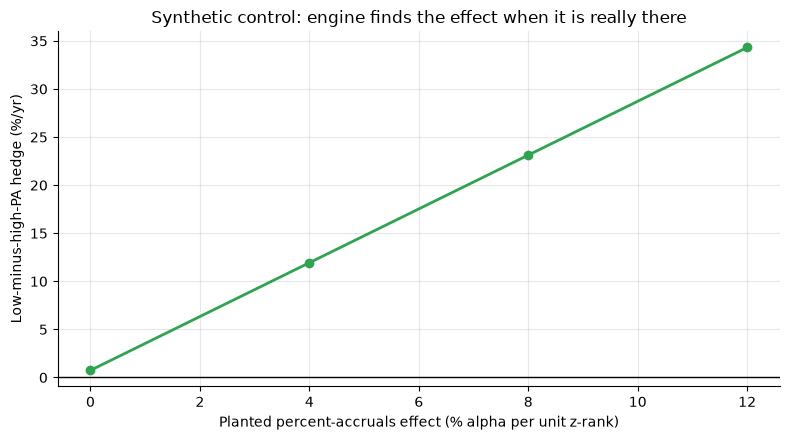

Engine faithfully recovers planted percent-accruals effects.


In [2]:
# Synthetic positive control: plant a known percent-accruals premium, confirm detection
premiums = [0.0, -0.04, -0.08, -0.12]
hedges = []
for p in premiums:
    s, f, _ = data.synthetic_panel(n_firms=300, n_years=25, premium=p, seed=522)
    hh = st.quintile_returns(s, f, q=0.20, min_names=15)
    hedges.append(hh['hedge'].mean() * 100)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot([abs(p)*100 for p in premiums], hedges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted percent-accruals effect (% alpha per unit z-rank)')
ax.set_ylabel('Low-minus-high-PA hedge (%/yr)')
ax.set_title('Synthetic control: engine finds the effect when it is really there')
plt.tight_layout(); plt.show()
print('Engine faithfully recovers planted percent-accruals effects.')

**Now the real tape -- quintile sort on percent accruals, year by year:**

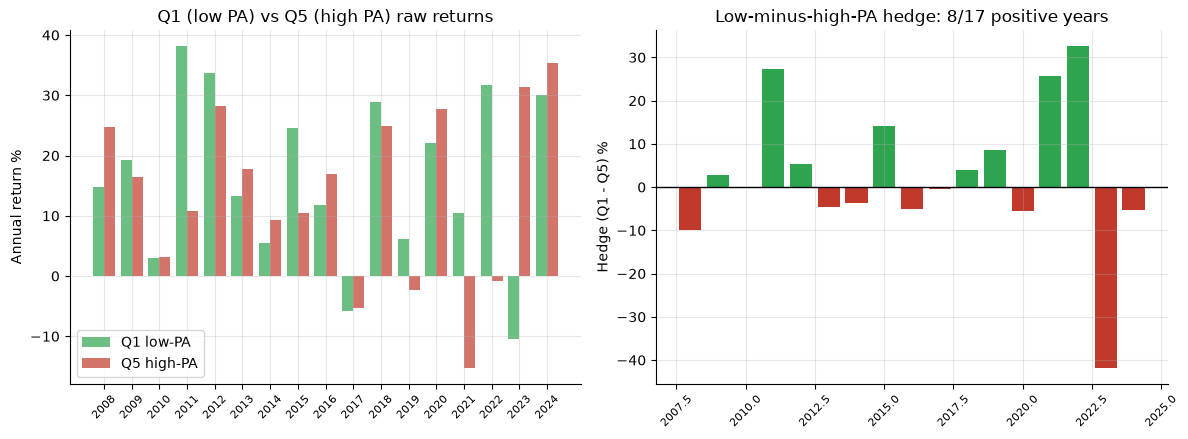

Mean hedge: +2.6%/yr  (frozen R: +2.6%/yr)


In [3]:
# Year-by-year low-PA vs high-PA vs hedge
if HAVE_REAL:
    q1_vals = h['q1'].values * 100
    q5_vals = h['q5'].values * 100
    hdg_vals = h['hedge'].values * 100
    years_real = [int(y) for y in h.index.tolist()]
else:
    q1_vals, q5_vals, hdg_vals, years_real = Q1, Q5, HDG, YRS
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = range(len(years_real))
axes[0].bar(x, q1_vals, label='Q1 low-PA', color=GREEN, alpha=0.7, width=0.4)
axes[0].bar([i+0.4 for i in x], q5_vals, label='Q5 high-PA', color=RED, alpha=0.7, width=0.4)
axes[0].set_xticks([i+0.2 for i in x])
axes[0].set_xticklabels(years_real, rotation=45, fontsize=8)
axes[0].set_ylabel('Annual return %'); axes[0].legend()
axes[0].set_title('Q1 (low PA) vs Q5 (high PA) raw returns')
colors = [GREEN if v > 0 else RED for v in hdg_vals]
axes[1].bar(years_real, hdg_vals, color=colors)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('Hedge (Q1 - Q5) %')
axes[1].set_title(f'Low-minus-high-PA hedge: {sum(1 for v in hdg_vals if v>0)}/{len(hdg_vals)} positive years')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); plt.show()
print('Mean hedge: %+.1f%%/yr  (frozen R: +%.1f%%/yr)' % (np.mean(hdg_vals), R['hedge_gross']))

The hedge is **+2.6%/yr gross** but positive in only 47% of years, with a brutal **-41.8% in 2023**. The quintile sort is **non-monotone** -- the low-PA leg barely separates from the high-PA leg (low-PA excess +0.6%/yr, *t* = +0.29; high-PA excess -2.0%/yr, *t* = -1.06). This is noise, not the sharp HLVW spread.

## 5 - The verdict

- **Signal -- None.** Hedge +2.6%/yr, HAC *t* = 0.84; label-shuffle placebo *p* = 0.46 (indistinguishable from random); the low-PA basket beats only 54% of random same-size draws. And this is a survivorship-biased upper bound.
- **Tradability -- Mirage.** Annual rebalancing is cheap (62%/yr turnover), but net *t* = 0.64 -- a tradable wrapper around a non-signal.
- **HLVW sharper sort? -- Busted.** Sloan's asset-scaled accrual reached *t* = +2.73 on a comparable survivor panel (Study 231); this earnings-scaled version lands +0.84. On large-cap survivors the percent-scaling does *not* sharpen the sort.

## 6 - Could you actually trade it?

Mechanically, yes -- 40 liquid large caps, one rebalance a year. But there is nothing to harvest:

1. **No edge.** Gross +2.6%/yr at *t* = 0.84 is well inside the noise band; the placebo says a coin-flip relabelling does as well.
2. **You'd pay to short nothing.** The high-PA short leg's underperformance (-2.0%/yr, *t* = -1.06) is the only directionally-correct piece and it is insignificant -- you would pay 50 bps/yr borrow for it.
3. **Wrong universe.** Both accrual flavours survive mainly in small, illiquid, low-coverage names -- the opposite of this basket.

The right conclusion: **MIRAGE** on this panel.

## 7 - Going further

- **The right universe.** HLVW (2011) ran value-weighted deciles on all US stocks 1989-2008. A point-in-time Compustat universe with small caps is the minimum for a credible percent-accruals test.
- **Percent *total* accruals.** HLVW also test the broader Richardson et al. balance-sheet accrual scaled by earnings; a natural extension.
- **The asset-scaled cousin.** [Study 231 -- Sloan-Accruals](../../231-sloan-accruals/) is the head-to-head benchmark -- same operating accrual, divided by assets.
- **Earnings-quality lens.** [Study 122 -- Gross-Profit](../../122-gross-profit/) and [Study 153 -- Net-Operating-Assets](../../153-net-operating-assets/) are the cousins.

*Think percent accruals still beat Sloan in a broad universe? Fork this, extend to a point-in-time all-US panel, and show |t| >= 2 on the spread. That's the missing half.*